In [1]:

import numpy as np
import pandas as pd

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

import kagglehub

/kaggle/input/datasets/vanessadellaquila/handpdtesi/HandPD_Dataset/confusion_matrix_cv.png
/kaggle/input/datasets/vanessadellaquila/handpdtesi/HandPD_Dataset/Meander_HandPD.csv
/kaggle/input/datasets/vanessadellaquila/handpdtesi/HandPD_Dataset/paper_style_metrics_baseline_rgb.csv
/kaggle/input/datasets/vanessadellaquila/handpdtesi/HandPD_Dataset/cv_fold_metrics.csv
/kaggle/input/datasets/vanessadellaquila/handpdtesi/HandPD_Dataset/Spiral_HandPD.csv
/kaggle/input/datasets/vanessadellaquila/handpdtesi/HandPD_Dataset/paper_style_metrics_vgg16_baseline_rgb.csv
/kaggle/input/datasets/vanessadellaquila/handpdtesi/HandPD_Dataset/cv_fold_metrics_vgg16_baseline_rgb.csv
/kaggle/input/datasets/vanessadellaquila/handpdtesi/HandPD_Dataset/confusion_matrix_cv_vgg16_baseline_rgb.png
/kaggle/input/datasets/vanessadellaquila/handpdtesi/HandPD_Dataset/outputs/features/0100-4__overlap_categorical.npy
/kaggle/input/datasets/vanessadellaquila/handpdtesi/HandPD_Dataset/outputs/features/0068-4__curvature.npy

In [2]:

# Import e Setup
import os
import re
import copy
import random
import itertools
from pathlib import Path
 
import numpy as np
import pandas as pd
import cv2
# Disabilita il multithreading interno di OpenCV: con i worker paralleli del
# DataLoader (creati via fork) i thread interni di cv2 possono produrre dati
# corrotti in modo non deterministico (es. shape errate). Con num_workers>0
# è buona norma disattivarlo.
cv2.setNumThreads(0)
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import functional as TF
from torchvision import models
from PIL import Image
from scipy.ndimage import distance_transform_edt, binary_dilation, gaussian_filter
from skimage.morphology import skeletonize, disk
from scipy.spatial import cKDTree
from sklearn.model_selection import GroupKFold, GroupShuffleSplit
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, classification_report,
    roc_auc_score, average_precision_score
)
import matplotlib.pyplot as plt
import seaborn as sns
 
# Seed fisso per la riproducibilità
# Copre tutte le fonti di casualità: inizializzazione dei pesi, ordine del
# DataLoader e augmentation di HandPDAblationDataset (che usa random.random()
# e random.uniform() direttamente, non le trasformazioni di torchvision).
SEED = 42
 
 
def set_seed(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
 
 
def seed_worker(worker_id):
    """Da passare come worker_init_fn ai DataLoader con num_workers > 0.
    Senza questo, i processi worker ereditano lo stesso stato casuale dal
    processo principale al momento del fork, e possono applicare la STESSA
    augmentation (stesso flip, stesso angolo) a immagini diverse elaborate
    da worker diversi in parallelo."""
    worker_seed = torch.initial_seed() % (2**32)
    np.random.seed(worker_seed)
    random.seed(worker_seed)
 
 
set_seed(SEED)
print(f"Seed fissato a {SEED} per riproducibilità.")
 
# Su Kaggle i dati caricati come "Dataset" sono montati in sola lettura
# sotto /kaggle/input/<nome-dataset>/, mentre l'unica cartella scrivibile
# è /kaggle/working/ (il suo contenuto resta disponibile come "Output" del notebook).
INPUT_BASE_DIR = Path('/kaggle/input/datasets/vanessadellaquila/handpdtesi/HandPD_Dataset')
 
 
def _find_dataset_root(search_root: Path) -> Path:
    """Cerca ricorsivamente, sotto search_root, la cartella che contiene
    davvero 'Meander_HandPD.csv' — gestisce automaticamente eventuali
    livelli di nidificazione extra introdotti dall'estrazione dello zip
    caricato su Kaggle."""
    if (search_root / 'Meander_HandPD.csv').exists():
        return search_root
    matches = list(search_root.rglob('Meander_HandPD.csv'))
    if matches:
        found_root = matches[0].parent
        print(f"NOTA: 'Meander_HandPD.csv' non era nella cartella attesa "
              f"({search_root}), ma è stato trovato automaticamente in "
              f"{found_root} — uso questo percorso.")
        return found_root
    raise FileNotFoundError(
        f"Non trovo 'Meander_HandPD.csv' da nessuna parte sotto {search_root}. "
        f"Verifica il nome esatto del dataset caricato (pannello 'Data' a destra "
        f"nel notebook Kaggle, o 'Copy path' sul file che ti serve)."
    )
 
 
IMAGES_BASE_DIR = _find_dataset_root(INPUT_BASE_DIR)
MASKS_DIR       = IMAGES_BASE_DIR / 'outputs' / 'masks'
 
# Cache delle feature: se presente nel dataset caricato viene letta da lì;
# i file mancanti vengono ricalcolati e scritti SOLO in /kaggle/working/
# (l'input è read-only).
FEATURES_DIR_INPUT = IMAGES_BASE_DIR / 'outputs' / 'features'   # eventuale cache già pronta (sola lettura)
FEATURES_DIR        = Path('/kaggle/working/outputs/features')  # cache effettiva usata dallo script (scrivibile)
RESULTS_DIR          = Path('/kaggle/working/outputs/ablation_results')
 
FEATURES_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
 
# Se esiste una cache pre-calcolata nell'input, viene copiata una sola volta
# nella cartella scrivibile, così da non ricalcolare ciò che è già pronto.
if FEATURES_DIR_INPUT.exists():
    import shutil
    n_copied = 0
    for f in FEATURES_DIR_INPUT.glob('*.npy'):
        dest = FEATURES_DIR / f.name
        if not dest.exists():
            shutil.copy2(f, dest)
            n_copied += 1
    print(f"Cache pre-esistente trovata nell'input: {n_copied} file copiati in {FEATURES_DIR}")
else:
    print("Nessuna cache pre-esistente trovata nell'input: verrà calcolata da zero (Cella 4).")
 
# Risoluzione di elaborazione (per calcolare le feature a scala
# consistente tra immagini di risoluzione nativa diversa) e risoluzione
# finale in ingresso alla rete.
PROCESSING_SIZE = 256
TARGET_SIZE     = 128
 
SAVE_FOLD_WEIGHTS = False
 
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"IMAGES_BASE_DIR: {IMAGES_BASE_DIR}")
print(f"MASKS_DIR: {MASKS_DIR}")
if not MASKS_DIR.exists():
    print(f"ATTENZIONE: {MASKS_DIR} non esiste — controlla se le maschere sono "
          f"nidificate diversamente (es. cerca 'outputs/masks' con la cella "
          f"diagnostica: !find /kaggle/input -iname 'masks' -type d).")
else:
    n_masks = len(list(MASKS_DIR.glob('*.npy')))
    print(f"  -> {n_masks} file .npy trovati in MASKS_DIR (attesi: 730, cioè 365 immagini x 2 maschere)")
print(f"FEATURES_DIR: {FEATURES_DIR}")
print(f"RESULTS_DIR: {RESULTS_DIR}")
print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")
if device.type != 'cuda':
    print("ATTENZIONE: nessuna GPU rilevata — verifica Settings > Accelerator > GPU nel notebook Kaggle.")

Seed fissato a 42 per riproducibilità.
Cache pre-esistente trovata nell'input: 2555 file copiati in /kaggle/working/outputs/features
IMAGES_BASE_DIR: /kaggle/input/datasets/vanessadellaquila/handpdtesi/HandPD_Dataset
MASKS_DIR: /kaggle/input/datasets/vanessadellaquila/handpdtesi/HandPD_Dataset/outputs/masks
  -> 1472 file .npy trovati in MASKS_DIR (attesi: 730, cioè 365 immagini x 2 maschere)
FEATURES_DIR: /kaggle/working/outputs/features
RESULTS_DIR: /kaggle/working/outputs/ablation_results
PyTorch version: 2.10.0+cu128
Device: cuda


In [3]:

# Caricamento Metadati: immagini + verifica maschere disponibili
DEFAULT_SEARCH_DIRS = [
    "MeanderHandPD", "Meander_HandPD",
    "SpiralHandPD", "Spiral_HandPD",
]
 
 
def infer_label_and_type(image_path: Path):
    parts_lower = [p.lower() for p in image_path.parts]
    label = None
    for p in parts_lower:
        if 'control' in p:
            label = 0
        elif 'patient' in p:
            label = 1
    draw_type = None
    for p in parts_lower:
        if 'spiral' in p:
            draw_type = 'Spiral'
        elif 'meander' in p:
            draw_type = 'Meander'
    return label, draw_type
 
 
def find_dataset_images(root_dir: Path):
    images = []
    for sub in DEFAULT_SEARCH_DIRS:
        d = root_dir / sub
        if d.exists():
            images.extend(sorted(d.rglob("*.jpg")))
            images.extend(sorted(d.rglob("*.png")))
    return images
 
 
def build_true_patient_lookup(base_dir: Path):
    """Costruisce, a partire dai CSV ufficiali del dataset, una lookup
    {(DRAW_TYPE, IMAGE_NAME_FISICO): vero_id_persona}.

    Il nome file riportato in IMAGE_NAME nel CSV NON corrisponde sempre al
    nome fisico su disco. Per i tracciati Meander, il CSV rinumera
    localmente i 4 tentativi di ogni sessione come -1..-4, mentre su disco
    gli stessi 4 tentativi sono salvati come -5..-8 (numerazione globale
    della sessione, che includeva anche i 4 tentativi Spiral come -1..-4).

    L'appaiamento avviene per POSIZIONE all'interno della stessa sessione
    (_ID_EXAM): i file fisici sono ordinati per suffisso numerico crescente
    e le righe CSV nel loro ordine originale. Non assume un offset fisso,
    quindi resta valido anche per le Spiral (dove il nome fisico coincide
    già col CSV). Le sessioni in cui il numero di righe CSV non coincide con
    quello dei file fisici trovati vengono escluse (e stampate a schermo)
    invece di essere appaiate alla cieca."""
    base_dir = Path(base_dir)  # accetta sia str sia Path
    lookup = {}
 
    csv_map = {
        'Meander': base_dir / 'Meander_HandPD.csv',
        'Spiral':  base_dir / 'Spiral_HandPD.csv',
    }
 
    # Directory fisiche in cui cercare i file per ciascun tipo, per
    # ricostruire il pairing posizionale reale (non solo dal CSV).
    physical_dirs = {
        'Meander': [base_dir / "MeanderHandPD", base_dir / "Meander_HandPD"],
        'Spiral':  [base_dir / "SpiralHandPD",  base_dir / "Spiral_HandPD"],
    }
 
    for draw_type, csv_path in csv_map.items():
        if not csv_path.exists():
            print(f"ATTENZIONE: CSV non trovato per {draw_type}: {csv_path}.")
            continue
 
        csv_df = pd.read_csv(csv_path)
 
        # Raccogli tutti i file fisici di questo tipo, ovunque si trovino
        physical_files = []
        for d in physical_dirs[draw_type]:
            if d.exists():
                physical_files.extend(d.rglob("*.jpg"))
                physical_files.extend(d.rglob("*.png"))
 
        # Raggruppa i file fisici per prefisso sessione (_ID_EXAM, 4 cifre)
        physical_by_exam = {}
        for p in physical_files:
            m = re.match(r'(\d+)-(\d+)\.\w+', p.name)
            if not m:
                continue
            exam_prefix, suffix = m.group(1), int(m.group(2))
            physical_by_exam.setdefault(exam_prefix, []).append((suffix, p.name))
 
        n_matched, n_mismatch = 0, 0
        for exam_id, group in csv_df.groupby('_ID_EXAM'):
            exam_prefix = f"{int(exam_id):04d}"
            physical_group = sorted(physical_by_exam.get(exam_prefix, []))
            csv_rows = group.to_dict('records')  # ordine originale nel CSV
 
            if len(physical_group) != len(csv_rows):
                n_mismatch += 1
                continue  # non appaiare alla cieca se i conteggi non tornano
 
            for (_, physical_name), row in zip(physical_group, csv_rows):
                lookup[(draw_type, physical_name)] = f"{int(row['CLASS_TYPE'])}_{int(row['ID_PATIENT'])}"
                n_matched += 1
 
        print(f"[{draw_type}] sessioni appaiate: {n_matched} immagini, "
              f"{n_mismatch} sessioni con conteggio non corrispondente (escluse)")
 
    return lookup
 
def load_metadata_with_masks(base_dir: Path, masks_dir: Path):
    images = find_dataset_images(base_dir)
    patient_lookup = build_true_patient_lookup(base_dir)
 
    rows = []
    skipped_no_label, skipped_no_masks, skipped_no_patient_match = 0, 0, 0
 
    for image_path in images:
        label, draw_type = infer_label_and_type(image_path)
        if label is None or draw_type is None:
            skipped_no_label += 1
            continue
 
        stem = image_path.stem
        blue_path  = masks_dir / f"{stem}_blue_mask.npy"
        black_path = masks_dir / f"{stem}_black_mask.npy"
 
        if not (blue_path.exists() and black_path.exists()):
            skipped_no_masks += 1
            continue
 
        # Vero identificativo di persona, letto dal CSV ufficiale
        # (CLASS_TYPE + ID_PATIENT), NON dal prefisso del nome file
        # (che è _ID_EXAM, identificativo di seduta, non di persona).
        true_patient_id = patient_lookup.get((draw_type, image_path.name))
        if true_patient_id is None:
            skipped_no_patient_match += 1
            continue
 
        rows.append({
            'STEM': stem,
            'IMAGE_PATH': str(image_path),
            'BLUE_MASK_PATH': str(blue_path),
            'BLACK_MASK_PATH': str(black_path),
            'LABEL': label,
            'DRAW_TYPE': draw_type,
            'ID_PATIENT': true_patient_id,
        })
 
    df = pd.DataFrame(rows)
 
    print(f"Immagini trovate nel dataset: {len(images)}")
    print(f"  -> scartate (cartella non riconosciuta come Control/Patient): {skipped_no_label}")
    print(f"  -> scartate (maschere .npy mancanti): {skipped_no_masks}")
    print(f"  -> scartate (nessuna corrispondenza nel CSV ufficiale, ID paziente non verificabile): {skipped_no_patient_match}")
    print(f"  -> utilizzabili (immagine + maschere + ID paziente verificato dal CSV): {len(df)}")
 
    return df
 
 
df = load_metadata_with_masks(IMAGES_BASE_DIR, MASKS_DIR)
 
if df.empty:
    raise ValueError(
        "Nessuna immagine con maschere disponibili trovata. Verifica che "
        "run_segmentation_demo.py sia stato eseguito e che i file .npy "
        f"siano in {MASKS_DIR}"
    )
 
print(f"\nDistribuzione classi:\n{df['LABEL'].value_counts().rename({0:'Control', 1:'Patient'})}")
print(f"Pazienti unici: {df['ID_PATIENT'].nunique()}")

[Meander] sessioni appaiate: 368 immagini, 0 sessioni con conteggio non corrispondente (escluse)
[Spiral] sessioni appaiate: 368 immagini, 0 sessioni con conteggio non corrispondente (escluse)
Immagini trovate nel dataset: 736
  -> scartate (cartella non riconosciuta come Control/Patient): 0
  -> scartate (maschere .npy mancanti): 0
  -> scartate (nessuna corrispondenza nel CSV ufficiale, ID paziente non verificabile): 0
  -> utilizzabili (immagine + maschere + ID paziente verificato dal CSV): 736

Distribuzione classi:
LABEL
Patient    592
Control    144
Name: count, dtype: int64
Pazienti unici: 54


In [4]:

# Feature Extraction: le 7 mappe derivate
def _propagate_skeleton_values(skeleton: np.ndarray, values_on_skeleton: np.ndarray) -> np.ndarray:
    """Assegna a ogni pixel dell'immagine il valore del punto di
    scheletro più vicino (nearest-neighbor), per ottenere una mappa
    piena a partire da valori definiti solo sui pixel dello scheletro."""
    if not skeleton.any():
        return np.zeros(skeleton.shape, dtype=np.float32)
    _, indices = distance_transform_edt(~skeleton, return_indices=True)
    inds_y, inds_x = indices[0], indices[1]
    return values_on_skeleton[inds_y, inds_x].astype(np.float32)
 
 
def get_patient_channel(patient_mask: np.ndarray) -> np.ndarray:
    """1) Tratto Paziente: maschera binaria del tratto blu."""
    return patient_mask.astype(np.float32)
 
 
def get_template_channel(template_mask: np.ndarray) -> np.ndarray:
    """2) Template: maschera binaria del tratto guida nero."""
    return template_mask.astype(np.float32)
 
 
def compute_signed_distance_map(patient_mask, template_mask, tolerance_radius=5):
    """3) Signed Distance Map: distanza dal tratto paziente, con segno
    negativo dentro la banda di tolleranza attorno al template,
    positivo fuori."""
    patient_mask  = patient_mask.astype(bool)
    template_mask = template_mask.astype(bool)
 
    dist_to_patient = distance_transform_edt(~patient_mask).astype(np.float32)
    tube = binary_dilation(template_mask, structure=disk(tolerance_radius))
    sign = np.where(tube, -1.0, 1.0).astype(np.float32)
 
    return dist_to_patient * sign
 
 
def compute_local_stroke_width(template_mask):
    """4) Local Stroke Width: spessore locale del tratto template,
    calcolato sullo scheletro e propagato a tutta l'immagine."""
    template_mask = template_mask.astype(bool)
    if not template_mask.any():
        return np.zeros(template_mask.shape, dtype=np.float32)
 
    skeleton = skeletonize(template_mask)
    radius_map = distance_transform_edt(template_mask)
    width_at_skeleton = np.where(skeleton, radius_map * 2.0, 0.0).astype(np.float32)
 
    return _propagate_skeleton_values(skeleton, width_at_skeleton)
 
 
def _order_skeleton_points(skeleton: np.ndarray, max_jump: float = 2.5):
    """Ordina i pixel dello scheletro con un cammino greedy basato sul
    vicino più prossimo (parametrizzazione approssimata per ascissa
    curvilinea). In presenza di diramazioni/interruzioni il cammino
    può 'saltare' al punto libero più vicino, introducendo una
    discontinuità locale nella curvatura in quel punto — accettabile
    per una feature euristica di questo tipo."""
    coords = np.argwhere(skeleton)
    if len(coords) < 3:
        return coords
 
    tree = cKDTree(coords)
    visited = np.zeros(len(coords), dtype=bool)
    start_idx = np.lexsort((coords[:, 1], coords[:, 0]))[0]
 
    order = [start_idx]
    visited[start_idx] = True
    current = start_idx
 
    for _ in range(len(coords) - 1):
        dists, idxs = tree.query(coords[current], k=min(8, len(coords)))
        idxs, dists = np.atleast_1d(idxs), np.atleast_1d(dists)
        next_idx = None
        for d, i in zip(dists, idxs):
            if not visited[i] and d <= max_jump:
                next_idx = i
                break
        if next_idx is None:
            remaining = np.where(~visited)[0]
            if len(remaining) == 0:
                break
            remaining_coords = coords[remaining]
            d2 = np.sum((remaining_coords - coords[current]) ** 2, axis=1)
            next_idx = remaining[np.argmin(d2)]
        order.append(next_idx)
        visited[next_idx] = True
        current = next_idx
 
    return coords[order]
 
 
def compute_local_curvature(template_mask, smoothing_sigma=2.0):
    """5) Local Curvature: κ=|dθ/ds| lungo lo scheletro parametrizzato
    per ascissa curvilinea, propagata a tutta l'immagine."""
    template_mask = template_mask.astype(bool)
    if not template_mask.any():
        return np.zeros(template_mask.shape, dtype=np.float32)
 
    skeleton = skeletonize(template_mask)
    ordered_points = _order_skeleton_points(skeleton)
 
    if len(ordered_points) < 5:
        return np.zeros(template_mask.shape, dtype=np.float32)
 
    ys, xs = ordered_points[:, 0].astype(np.float64), ordered_points[:, 1].astype(np.float64)
 
    ys_s = gaussian_filter(ys, sigma=smoothing_sigma)
    xs_s = gaussian_filter(xs, sigma=smoothing_sigma)
 
    dy, dx = np.gradient(ys_s), np.gradient(xs_s)
    theta_unwrapped = np.unwrap(np.arctan2(dy, dx))
 
    ds = np.sqrt(dy**2 + dx**2)
    ds[ds < 1e-6] = 1e-6
 
    dtheta = np.gradient(theta_unwrapped)
    kappa = np.abs(dtheta / ds).astype(np.float32)
 
    values_on_skeleton = np.zeros(template_mask.shape, dtype=np.float32)
    values_on_skeleton[ys.astype(int), xs.astype(int)] = kappa
 
    return _propagate_skeleton_values(skeleton, values_on_skeleton)
 
 
def compute_categorical_overlap(patient_mask, template_mask, one_hot=True):
    """6) Categorical Overlap Mask: 0=Sfondo, 1=Solo Template,
    2=Intersezione, 3=Solo Paziente. Default one-hot a 4 canali (valori
    ordinali 0-3 su un canale singolo implicherebbero una relazione
    d'ordine tra le classi che non esiste)."""
    patient_mask  = patient_mask.astype(bool)
    template_mask = template_mask.astype(bool)
 
    category = np.zeros(patient_mask.shape, dtype=np.int64)
    category[template_mask & ~patient_mask] = 1
    category[template_mask & patient_mask]  = 2
    category[~template_mask & patient_mask] = 3
 
    if one_hot:
        one_hot_map = np.eye(4, dtype=np.float32)[category]
        return np.transpose(one_hot_map, (2, 0, 1))
    return category.astype(np.float32)[None, ...]
 
 
def compute_error_density_heatmap(patient_mask, template_mask, tolerance_radius=5, sigma=4.0):
    """7) Error Density Heatmap: densità (smoothing gaussiano) dei
    pixel del paziente che cadono fuori dalla banda di tolleranza."""
    patient_mask  = patient_mask.astype(bool)
    template_mask = template_mask.astype(bool)
 
    tube = binary_dilation(template_mask, structure=disk(tolerance_radius))
    error_pixels = (patient_mask & ~tube).astype(np.float32)
 
    return gaussian_filter(error_pixels, sigma=sigma).astype(np.float32)
 
 
# Registro dei canali disponibili: nome -> (n_canali, categoriale?)
# 'categorical'=True indica che il canale ha natura discreta/binaria
# (usato per scegliere l'interpolazione in fase di resize).
CHANNEL_SPECS = {
    'patient':             {'n_channels': 1, 'categorical': True},
    'template':             {'n_channels': 1, 'categorical': True},
    'signed_distance':      {'n_channels': 1, 'categorical': False},
    'stroke_width':          {'n_channels': 1, 'categorical': False},
    'curvature':              {'n_channels': 1, 'categorical': False},
    'overlap_categorical':    {'n_channels': 4, 'categorical': True},
    'error_density':          {'n_channels': 1, 'categorical': False},
}
 
 
def compute_all_channels(patient_mask_proc: np.ndarray, template_mask_proc: np.ndarray) -> dict:
    """Calcola tutte le 7 mappe a partire dalle maschere GIA' portate
    alla risoluzione di elaborazione (PROCESSING_SIZE). Restituisce un
    dizionario {nome_canale: array (n_channels, H, W) float32}."""
    result = {
        'patient':            get_patient_channel(patient_mask_proc)[None, ...],
        'template':            get_template_channel(template_mask_proc)[None, ...],
        'signed_distance':     compute_signed_distance_map(patient_mask_proc, template_mask_proc)[None, ...],
        'stroke_width':         compute_local_stroke_width(template_mask_proc)[None, ...],
        'curvature':             compute_local_curvature(template_mask_proc)[None, ...],
        'overlap_categorical':   compute_categorical_overlap(patient_mask_proc, template_mask_proc, one_hot=True),
        'error_density':         compute_error_density_heatmap(patient_mask_proc, template_mask_proc)[None, ...],
    }
 
    # Controllo difensivo: ogni mappa deve essere 3D (C,H,W) con C pari
    # a quanto dichiarato in CHANNEL_SPECS. Intercetta subito eventuali
    # dimenticanze di [None, ...] invece di lasciarle propagare fino
    # al resize (dove causerebbero shape corrotte silenziosamente).
    for name, arr in result.items():
        expected_c = CHANNEL_SPECS[name]['n_channels']
        assert arr.ndim == 3 and arr.shape[0] == expected_c, (
            f"Canale '{name}': shape {arr.shape} non valida, attesi "
            f"{expected_c} canali su un array 3D (C,H,W)."
        )
 
    return result

In [5]:

# Precalcolo delle feature (cache su disco)
def resize_channel_map(channel_map: np.ndarray, target_size: int, categorical: bool) -> np.ndarray:
    """Ridimensiona una mappa (C, H, W) al target_size. Nearest per
    canali categoriali/binari (per non mescolare classi/creare valori
    intermedi non validi), bilineare per mappe continue."""
    interp = cv2.INTER_NEAREST if categorical else cv2.INTER_LINEAR
    C = channel_map.shape[0]
    resized = np.stack([
        cv2.resize(channel_map[c], (target_size, target_size), interpolation=interp)
        for c in range(C)
    ], axis=0)
    return resized.astype(np.float32)
 
 
def _cached_file_is_valid(path: Path, expected_channels: int) -> bool:
    """Verifica che un file .npy in cache esista E abbia la shape
    attesa (n_canali, TARGET_SIZE, TARGET_SIZE). Un file esistente ma
    con shape sbagliata (es. residuo di una run precedente con
    PROCESSING_SIZE/TARGET_SIZE diversi) NON viene considerato valido,
    per evitare di riusare silenziosamente una cache "sporca"."""
    if not path.exists():
        return False
    try:
        arr = np.load(path, mmap_mode='r')  # mmap: legge solo l'header, non l'intero array
    except Exception:
        return False
    expected_shape = (expected_channels, TARGET_SIZE, TARGET_SIZE)
    return arr.shape == expected_shape
 
 
def precompute_features_for_row(row) -> None:
    """Calcola e salva su disco le 7 mappe per un'immagine, pronte alla
    TARGET_SIZE per il training. Ricalcola SOLO i canali mancanti o con
    shape non valida in cache (idempotente e robusto a cache sporche)."""
    stem = row['STEM']
 
    names_to_compute = [
        name for name in CHANNEL_SPECS
        if not _cached_file_is_valid(
            FEATURES_DIR / f"{stem}__{name}.npy",
            CHANNEL_SPECS[name]['n_channels']
        )
    ]
    if not names_to_compute:
        return
 
    blue_mask_native  = np.load(row['BLUE_MASK_PATH'])
    black_mask_native = np.load(row['BLACK_MASK_PATH'])
 
    # Porta le maschere alla risoluzione di elaborazione comune, PRIMA
    # di calcolare le feature, così le distanze/spessori sono
    # confrontabili tra immagini di risoluzione nativa diversa.
    patient_mask_proc = cv2.resize(
        blue_mask_native.astype(np.uint8), (PROCESSING_SIZE, PROCESSING_SIZE),
        interpolation=cv2.INTER_NEAREST
    )
    template_mask_proc = cv2.resize(
        black_mask_native.astype(np.uint8), (PROCESSING_SIZE, PROCESSING_SIZE),
        interpolation=cv2.INTER_NEAREST
    )
 
    channels = compute_all_channels(patient_mask_proc, template_mask_proc)
 
    for name in names_to_compute:
        arr = channels[name]
        categorical = CHANNEL_SPECS[name]['categorical']
        arr_resized = resize_channel_map(arr, TARGET_SIZE, categorical)
        np.save(FEATURES_DIR / f"{stem}__{name}.npy", arr_resized)
 
 
print(f"\nPrecalcolo feature per {len(df)} immagini (skip automatico se già presenti in cache)...")
for i, row in df.iterrows():
    precompute_features_for_row(row)
    if (i + 1) % 50 == 0 or (i + 1) == len(df):
        print(f"  {i + 1}/{len(df)} completate")
print(f"Feature cache pronta in: {FEATURES_DIR}")


Precalcolo feature per 736 immagini (skip automatico se già presenti in cache)...
  50/736 completate
  100/736 completate
  150/736 completate
  200/736 completate
  250/736 completate
  300/736 completate
  350/736 completate
  400/736 completate
  450/736 completate
  500/736 completate
  550/736 completate
  600/736 completate
  650/736 completate
  700/736 completate
  736/736 completate
Feature cache pronta in: /kaggle/working/outputs/features


In [6]:

# Dataset PyTorch per l'Ablation Study
def rotate_map_nearest(arr: np.ndarray, angle: float) -> np.ndarray:
    """Ruota una mappa 2D (singolo canale) con interpolazione nearest,
    per non introdurre valori intermedi non validi (usata in modo
    uniforme su tutti i canali per garantire trasformazioni coerenti
    tra loro durante l'augmentation)."""
    h, w = arr.shape
    rot_matrix = cv2.getRotationMatrix2D((w / 2, h / 2), angle, 1.0)
    return cv2.warpAffine(arr, rot_matrix, (w, h), flags=cv2.INTER_NEAREST, borderValue=0)
 
 
class HandPDAblationDataset(Dataset):
    """Dataset per lo studio ablativo: carica dalla cache su disco solo
    i canali richiesti in channels_to_use, li concatena lungo l'asse
    canale e restituisce un tensore (C, H, W) insieme alla label.
 
    Se train=True, applica flip orizzontale e rotazione casuali, con
    LO STESSO parametro casuale su TUTTI i canali selezionati, per
    mantenerli spazialmente allineati tra loro."""
 
    def __init__(self, dataframe: pd.DataFrame, channels_to_use: list, train: bool):
        self.df = dataframe.reset_index(drop=True)
        self.channels_to_use = channels_to_use
        self.train = train
 
        unknown = [c for c in channels_to_use if c not in CHANNEL_SPECS]
        if unknown:
            raise ValueError(f"Canali non riconosciuti: {unknown}. "
                              f"Disponibili: {list(CHANNEL_SPECS.keys())}")
 
    def __len__(self):
        return len(self.df)
 
    def total_channels(self) -> int:
        return sum(CHANNEL_SPECS[c]['n_channels'] for c in self.channels_to_use)
 
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        stem = row['STEM']
 
        channel_arrays = [
            np.load(FEATURES_DIR / f"{stem}__{name}.npy")  # shape (n_channels_i, H, W)
            for name in self.channels_to_use
        ]
        stacked = np.concatenate(channel_arrays, axis=0)  # (C_totale, H, W)
 
        expected_c = self.total_channels()
        if stacked.shape != (expected_c, TARGET_SIZE, TARGET_SIZE):
            raise RuntimeError(
                f"Shape della cache non valida per '{stem}': trovata {stacked.shape}, "
                f"attesa ({expected_c}, {TARGET_SIZE}, {TARGET_SIZE}). "
                f"Probabile cache 'sporca' in {FEATURES_DIR} — svuota la cartella "
                f"outputs/features/ e riesegui la Cella 4 (precalcolo)."
            )
 
        if self.train:
            if random.random() < 0.5:
                stacked = np.ascontiguousarray(stacked[:, :, ::-1])
 
            angle = random.uniform(-10, 10)
            stacked = np.stack([rotate_map_nearest(stacked[c], angle) for c in range(stacked.shape[0])], axis=0)
 
        # Ridimensionamento a 224x224, richiesto da VGG16 (la cache è a 128x128).
        # Nearest per i canali categoriali/binari, bilineare per quelli continui —
        # stessa logica di interpolazione usata nel precalcolo della cache.
        categorical_flags = []
        for name in self.channels_to_use:
            categorical_flags.extend([CHANNEL_SPECS[name]['categorical']] * CHANNEL_SPECS[name]['n_channels'])
        stacked = np.stack([
            cv2.resize(stacked[c], (MODEL_INPUT_SIZE, MODEL_INPUT_SIZE),
                       interpolation=cv2.INTER_NEAREST if categorical_flags[c] else cv2.INTER_LINEAR)
            for c in range(stacked.shape[0])
        ], axis=0)
 
        tensor = torch.from_numpy(stacked.astype(np.float32))
        label_tensor = torch.tensor(row['LABEL'], dtype=torch.float32)
        return tensor, label_tensor
 
 
MODEL_INPUT_SIZE = 224  # risoluzione richiesta dai modelli pre-addestrati su ImageNet
BATCH_SIZE  = 16  # ridotto rispetto ai 32 della CNN custom: VGG16 a 224x224
                   # occupa molta più memoria GPU
# Se con i worker paralleli compaiono errori (shape corrotte, deadlock, crash
# silenziosi), impostare NUM_WORKERS = 0: il DataLoader carica i dati nel
# processo principale, più lento ma privo di problemi di concorrenza.
NUM_WORKERS = 2

In [7]:

# VGG16 con Transfer Learning, adattata al numero di canali
def _adapt_first_conv(old_conv: nn.Conv2d, new_in_channels: int) -> nn.Conv2d:
    """Sostituisce il primo layer convoluzionale per accettare un numero di
    canali diverso da 3, inizializzando i pesi come media dei pesi
    pre-addestrati sui 3 canali RGB, ripetuta per il nuovo numero di
    canali — così da preservare il più possibile la conoscenza appresa su
    ImageNet anche quando l'input non è un'immagine RGB standard."""
    new_conv = nn.Conv2d(
        in_channels=new_in_channels, out_channels=old_conv.out_channels,
        kernel_size=old_conv.kernel_size, stride=old_conv.stride,
        padding=old_conv.padding, bias=(old_conv.bias is not None),
    )
    with torch.no_grad():
        averaged = old_conv.weight.mean(dim=1, keepdim=True)
        new_conv.weight.copy_(averaged.repeat(1, new_in_channels, 1, 1))
        if old_conv.bias is not None:
            new_conv.bias.copy_(old_conv.bias)
    return new_conv
 
 
def build_vgg16_model(in_channels: int) -> nn.Module:
    """VGG16 pre-addestrata su ImageNet, backbone congelato (tranne il
    primo layer se adattato a canali != 3) e testa di classificazione
    sostituita per l'output binario."""
    model = models.vgg16(weights=models.VGG16_Weights.DEFAULT)
    if in_channels != 3:
        model.features[0] = _adapt_first_conv(model.features[0], in_channels)
    for p in model.parameters():
        p.requires_grad = False
    if in_channels != 3:
        for p in model.features[0].parameters():
            p.requires_grad = True
    model.classifier[6] = nn.Linear(model.classifier[6].in_features, 1)
    return model

In [8]:

# Dual-Branch Cross-Attention per VGG16
#
# VGG16.features è composta da 5 stadi naturali, separati da MaxPool2d:
#   stadio 1: layer[0:5]   -> 64 canali in uscita
#   stadio 2: layer[5:10]  -> 128 canali in uscita
#   stadio 3: layer[10:17] -> 256 canali in uscita
#   stadio 4: layer[17:24] -> 512 canali in uscita
#   stadio 5: layer[24:31] -> 512 canali in uscita
#
# Due copie di VGG16 (pesi indipendenti, backbone congelato tranne il
# primo conv adattato di ciascuna) processano i due gruppi di canali;
# dopo ciascuno dei 5 stadi, le feature map — alla stessa risoluzione
# spaziale, perché scendono di pari passo — si scambiano informazione
# tramite CrossAttentionBlock (la riduzione a griglia 8x8 per il calcolo
# dell'attenzione lo rende indipendente dalla risoluzione di input).
#
# Nota su BATCH_SIZE: con due copie di VGG16 attive contemporaneamente il
# consumo di memoria raddoppia; batch=32 satura la memoria disponibile,
# quindi si usa BATCH_SIZE=16.
 
CROSSATTN_POOL_SIZE = 8
VGG16_STAGE_BOUNDARIES = [(0, 5), (5, 10), (10, 17), (17, 24), (24, 31)]
VGG16_STAGE_CHANNELS = [64, 128, 256, 512, 512]
 
 
class CrossAttentionBlock(nn.Module):
    """Cross-attention bidirezionale tra due branch: ciascun branch usa le
    proprie feature come Query e quelle dell'altro branch come Key/Value.
    Le due direzioni partono entrambe dalle feature originali dello stadio
    corrente (non l'una dall'altra in sequenza), per restare simmetriche.
    L'attenzione è calcolata su una griglia ridotta (pool_size x pool_size)
    per sostenibilità computazionale; il risultato è riportato alla
    risoluzione originale via interpolazione bilineare e sommato alle
    feature come residuo."""
 
    def __init__(self, embed_dim: int, num_heads: int = 4, pool_size: int = CROSSATTN_POOL_SIZE):
        super().__init__()
        self.pool_size = pool_size
        self.pool = nn.AdaptiveAvgPool2d(pool_size)
        self.attn_a_from_b = nn.MultiheadAttention(embed_dim, num_heads, batch_first=True)
        self.attn_b_from_a = nn.MultiheadAttention(embed_dim, num_heads, batch_first=True)
        self.norm_a = nn.LayerNorm(embed_dim)
        self.norm_b = nn.LayerNorm(embed_dim)
 
    def forward(self, feat_a, feat_b):
        B, C, H, W = feat_a.shape
        a_pooled = self.pool(feat_a)
        b_pooled = self.pool(feat_b)
        tokens_a = a_pooled.flatten(2).transpose(1, 2)
        tokens_b = b_pooled.flatten(2).transpose(1, 2)
 
        attn_out_a, _ = self.attn_a_from_b(tokens_a, tokens_b, tokens_b)
        attn_out_b, _ = self.attn_b_from_a(tokens_b, tokens_a, tokens_a)
 
        tokens_a = self.norm_a(tokens_a + attn_out_a)
        tokens_b = self.norm_b(tokens_b + attn_out_b)
 
        attn_map_a = tokens_a.transpose(1, 2).reshape(B, C, self.pool_size, self.pool_size)
        attn_map_b = tokens_b.transpose(1, 2).reshape(B, C, self.pool_size, self.pool_size)
        attn_map_a = F.interpolate(attn_map_a, size=(H, W), mode='bilinear', align_corners=False)
        attn_map_b = F.interpolate(attn_map_b, size=(H, W), mode='bilinear', align_corners=False)
 
        return feat_a + attn_map_a, feat_b + attn_map_b
 
 
def build_vgg16_branch(in_channels: int) -> nn.ModuleList:
    """Una VGG16 pre-addestrata, primo conv adattato al numero di
    canali del branch, backbone congelato tranne il primo conv,
    splittata nei suoi 5 stadi naturali."""
    vgg = models.vgg16(weights=models.VGG16_Weights.DEFAULT)
    if in_channels != 3:
        vgg.features[0] = _adapt_first_conv(vgg.features[0], in_channels)
    for p in vgg.parameters():
        p.requires_grad = False
    if in_channels != 3:
        for p in vgg.features[0].parameters():
            p.requires_grad = True
    return nn.ModuleList([vgg.features[s:e] for s, e in VGG16_STAGE_BOUNDARIES])
 
 
class DualBranchCrossAttentionVGG16(nn.Module):
    """Due VGG16 (pesi indipendenti), una per branch, con
    cross-attention dopo ciascuno dei 5 stadi. Le uscite finali
    (dopo AdaptiveAvgPool a 7x7, come nella VGG16 originale) vengono
    concatenate prima di un nuovo classificatore leggero — la testa
    originale di VGG16 (4096 unità) non viene riusata, sostituita da
    una testa più contenuta."""
 
    def __init__(self, branch_a_channels: int, branch_b_channels: int):
        super().__init__()
        self.stages_a = build_vgg16_branch(branch_a_channels)
        self.stages_b = build_vgg16_branch(branch_b_channels)
        self.cross_attns = nn.ModuleList([CrossAttentionBlock(c) for c in VGG16_STAGE_CHANNELS])
        self.avgpool = nn.AdaptiveAvgPool2d((7, 7))
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(512 * 7 * 7 * 2, 256)
        self.relu_fc = nn.ReLU(inplace=True)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(256, 1)
 
    def forward(self, x_a, x_b):
        for stage_a, stage_b, cross_attn in zip(self.stages_a, self.stages_b, self.cross_attns):
            x_a = stage_a(x_a)
            x_b = stage_b(x_b)
            x_a, x_b = cross_attn(x_a, x_b)
        x_a = self.flatten(self.avgpool(x_a))
        x_b = self.flatten(self.avgpool(x_b))
        merged = torch.cat([x_a, x_b], dim=1)
        out = self.dropout(self.relu_fc(self.fc1(merged)))
        return self.fc2(out)
 
 
def branch_n_channels(channel_list: list) -> int:
    return sum(CHANNEL_SPECS[c]['n_channels'] for c in channel_list)
 
 
def split_branches(inputs, branch_a_size: int, branch_b_size: int):
    """Spacchetta il tensore concatenato prodotto dal Dataset nei due
    gruppi attesi dal modello a doppio branch. Richiede che
    channels_to_use sia esattamente [canali branch A] + [canali branch B]."""
    return torch.split(inputs, [branch_a_size, branch_b_size], dim=1)
 
 
PRIMARY_CHANNELS = ['patient', 'template']
DERIVED_CHANNELS = ['signed_distance', 'stroke_width', 'curvature', 'overlap_categorical', 'error_density']

In [9]:

# Funzioni di training/valutazione per un singolo fold
def train_one_fold(train_df, val_df, channels_to_use, branch_a_size, branch_b_size,
                    epochs, device, use_class_weighting=False):
    train_dataset = HandPDAblationDataset(train_df, channels_to_use, train=True)
    val_dataset   = HandPDAblationDataset(val_df,   channels_to_use, train=False)
 
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                               num_workers=NUM_WORKERS, pin_memory=True, worker_init_fn=seed_worker)
    val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                               num_workers=NUM_WORKERS, pin_memory=True, worker_init_fn=seed_worker)
 
    model = DualBranchCrossAttentionVGG16(
        branch_a_channels=branch_a_size, branch_b_channels=branch_b_size
    ).to(device)
 
    if use_class_weighting:
        # pos_weight agisce sulla classe "positiva" (Patient=1). Poiché Patient è
        # la classe MAGGIORITARIA nel nostro dataset (non la minoritaria, come
        # nel caso d'uso più comune di questo parametro), il rapporto
        # neg/pos risulta < 1: questo *riduce* il peso della classe Patient
        # nella loss invece di aumentarlo, ribilanciando correttamente
        # l'attenzione del modello verso la classe Control, sottorappresentata.
        # Il peso è calcolato SOLO sul training set di questo fold, per non
        # introdurre alcuna informazione dal test set (data leakage).
        n_control = (train_df['LABEL'] == 0).sum()
        n_patient = (train_df['LABEL'] == 1).sum()
        pos_weight_value = n_control / n_patient
        pos_weight = torch.tensor([pos_weight_value], dtype=torch.float32).to(device)
        criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
        print(f"    Class weighting attivo: pos_weight={pos_weight_value:.4f} "
              f"(train: {n_control} Control, {n_patient} Patient)")
    else:
        criterion = nn.BCEWithLogitsLoss()
 
    # Learning rate ridotto rispetto a 1e-3: l'architettura a doppio branch
    # con cross-attention residua a più stadi mostra instabilità di training
    # (picchi di loss) con il learning rate standard.
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
 
    best_val_loss = float('inf')
    best_state    = copy.deepcopy(model.state_dict())
 
    for epoch in range(1, epochs + 1):
 
        model.train()
        train_loss, train_correct, train_total = 0.0, 0, 0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
 
            optimizer.zero_grad()
            outputs = model(*split_branches(inputs, branch_a_size, branch_b_size)).squeeze(1)
            loss = criterion(outputs, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # rete di sicurezza aggiuntiva
            optimizer.step()
 
            train_loss    += loss.item()
            preds          = (torch.sigmoid(outputs) >= 0.5).float()
            train_correct += (preds == labels).sum().item()
            train_total   += labels.size(0)
 
        avg_train_loss = train_loss / len(train_loader)
        avg_train_acc  = train_correct / train_total
 
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(*split_branches(inputs, branch_a_size, branch_b_size)).squeeze(1)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                preds = (torch.sigmoid(outputs) >= 0.5).float()
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)
 
        avg_val_loss = val_loss / len(val_loader)
        avg_val_acc  = val_correct / val_total
        scheduler.step(avg_val_loss)
 
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_state    = copy.deepcopy(model.state_dict())
            marker = " <- best"
        else:
            marker = ""
 
        print(
            f"    Epoch {epoch:>2}/{epochs} | "
            f"Train Loss: {avg_train_loss:.4f} | Train Acc: {avg_train_acc:.4f} | "
            f"Val Loss: {avg_val_loss:.4f} | Val Acc: {avg_val_acc:.4f}{marker}"
        )
 
    model.load_state_dict(best_state)
    return model
 
 
def evaluate_model(model, eval_df, channels_to_use, branch_a_size, branch_b_size, device):
    eval_dataset = HandPDAblationDataset(eval_df, channels_to_use, train=False)
    eval_loader  = DataLoader(eval_dataset, batch_size=BATCH_SIZE, shuffle=False,
                               num_workers=NUM_WORKERS, pin_memory=True, worker_init_fn=seed_worker)
 
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for inputs, labels in eval_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(*split_branches(inputs, branch_a_size, branch_b_size)).squeeze(1)
            probs = torch.sigmoid(outputs)
            preds = (probs >= 0.5).float()
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
 
    return np.array(all_preds), np.array(all_labels), np.array(all_probs)
 
 
def compute_paper_style_metrics(y_true, y_pred, y_prob):
    """Le 5 metriche: Accuracy, Sensitivity (=Recall_Patient),
    Specificity (=Recall_Control), AUC, AUPR. AUC/AUPR richiedono le
    probabilità, non le predizioni già binarizzate."""
    acc = accuracy_score(y_true, y_pred)
    _, rec, _, _ = precision_recall_fscore_support(y_true, y_pred, labels=[0, 1], zero_division=0)
    return {
        'Accuracy': acc, 'Sensitivity': rec[1], 'Specificity': rec[0],
        'AUC': roc_auc_score(y_true, y_prob), 'AUPR': average_precision_score(y_true, y_prob),
    }
 
 
def print_both_classes_metrics(y_true, y_pred, header):
    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, support = precision_recall_fscore_support(
        y_true, y_pred, labels=[0, 1], zero_division=0
    )
    print("\n" + "-"*50)
    print(f"   {header}")
    print("-"*50)
    print(f"  Accuracy complessiva: {acc:.4f}")
    print(f"  {'Classe':<10}{'Precision':>12}{'Recall':>12}{'F1-Score':>12}{'Support':>10}")
    for cls, name in zip([0, 1], ['Control', 'Patient']):
        print(f"  {name:<10}{prec[cls]:>12.4f}{rec[cls]:>12.4f}{f1[cls]:>12.4f}{support[cls]:>10d}")
    print("-"*50)
    return {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1, 'support': support}

In [10]:

# Cross-Validation patient-aware, incapsulata per riuso
N_SPLITS = 5
EPOCHS   = 15  # meno delle 20 usate per BaselineCNN: con il backbone
               # VGG16 congelato la convergenza è tipicamente più rapida
VAL_FRACTION_WITHIN_FOLD = 0.15
 
 
def run_cross_validation(channels_to_use: list, branch_a_size: int, branch_b_size: int,
                          df: pd.DataFrame, experiment_name: str,
                          n_splits: int = N_SPLITS, epochs: int = EPOCHS, verbose: bool = True,
                          use_class_weighting: bool = False):
    """Esegue una GroupKFold CV patient-aware completa per una data
    combinazione di canali, e restituisce un dizionario riassuntivo
    con le metriche (media/std per fold + aggregate out-of-fold).
    branch_a_size e branch_b_size specificano come il tensore
    concatenato va spacchettato nei due branch del modello —
    channels_to_use deve essere ordinato come [canali branch A] +
    [canali branch B]. Se use_class_weighting=True, la loss di ogni
    fold pesa maggiormente gli errori sulla classe minoritaria
    (Control), con il peso ricalcolato ad ogni fold sul solo training
    set di quel fold."""
 
    gkf = GroupKFold(n_splits=n_splits)
    fold_metrics, oof_preds, oof_labels, oof_probs = [], [], [], []
    paper_fold_metrics = []
 
    print(f"\n{'#'*70}")
    print(f"# ESPERIMENTO: {experiment_name}  |  canali: {channels_to_use}  |  "
          f"class_weighting: {use_class_weighting}")
    print(f"{'#'*70}")
 
    for fold, (trainval_idx, test_idx) in enumerate(gkf.split(df, groups=df['ID_PATIENT']), start=1):
 
        trainval_df = df.iloc[trainval_idx].reset_index(drop=True)
        test_df     = df.iloc[test_idx].reset_index(drop=True)
 
        gss_val = GroupShuffleSplit(n_splits=1, test_size=VAL_FRACTION_WITHIN_FOLD, random_state=42)
        train_idx, val_idx = next(gss_val.split(trainval_df, groups=trainval_df['ID_PATIENT']))
 
        train_df = trainval_df.iloc[train_idx].reset_index(drop=True)
        val_df   = trainval_df.iloc[val_idx].reset_index(drop=True)
 
        train_patients = set(train_df['ID_PATIENT'])
        val_patients   = set(val_df['ID_PATIENT'])
        test_patients  = set(test_df['ID_PATIENT'])
        assert len(train_patients & val_patients) == 0
        assert len(train_patients & test_patients) == 0
        assert len(val_patients   & test_patients) == 0
 
        if verbose:
            print(f"\n  FOLD {fold}/{n_splits} | "
                  f"Train: {len(train_df)} img | Val: {len(val_df)} img | Test: {len(test_df)} img")
 
        model = train_one_fold(train_df, val_df, channels_to_use, branch_a_size, branch_b_size,
                                epochs=epochs, device=device,
                                use_class_weighting=use_class_weighting)
        preds, labels, probs = evaluate_model(model, test_df, channels_to_use,
                                               branch_a_size, branch_b_size, device)
 
        metrics = print_both_classes_metrics(labels, preds, header=f"{experiment_name} - FOLD {fold}")
        metrics['fold'] = fold
        fold_metrics.append(metrics)
 
        paper_metrics = compute_paper_style_metrics(labels, preds, probs)
        paper_metrics['fold'] = fold
        paper_fold_metrics.append(paper_metrics)
 
        oof_preds.append(preds)
        oof_labels.append(labels)
        oof_probs.append(probs)
 
    oof_preds  = np.concatenate(oof_preds)
    oof_labels = np.concatenate(oof_labels)
    oof_probs  = np.concatenate(oof_probs)
 
    mean_acc = np.mean([m['accuracy'] for m in fold_metrics])
    std_acc  = np.std([m['accuracy'] for m in fold_metrics])
    mean_prec = np.mean([m['precision'] for m in fold_metrics], axis=0)
    mean_rec  = np.mean([m['recall'] for m in fold_metrics], axis=0)
    mean_f1   = np.mean([m['f1'] for m in fold_metrics], axis=0)
    std_prec  = np.std([m['precision'] for m in fold_metrics], axis=0)
    std_rec   = np.std([m['recall'] for m in fold_metrics], axis=0)
    std_f1    = np.std([m['f1'] for m in fold_metrics], axis=0)
 
    oof_metrics = print_both_classes_metrics(
        oof_labels, oof_preds, header=f"{experiment_name} - AGGREGATO OUT-OF-FOLD"
    )
    oof_paper_metrics = compute_paper_style_metrics(oof_labels, oof_preds, oof_probs)
 
    return {
        'experiment_name': experiment_name,
        'channels': channels_to_use,
        'n_input_channels': sum(CHANNEL_SPECS[c]['n_channels'] for c in channels_to_use),
        'mean_accuracy': mean_acc, 'std_accuracy': std_acc,
        'mean_precision': mean_prec, 'std_precision': std_prec,
        'mean_recall': mean_rec, 'std_recall': std_rec,
        'mean_f1': mean_f1, 'std_f1': std_f1,
        'oof_accuracy': oof_metrics['accuracy'],
        'oof_precision': oof_metrics['precision'], 'oof_recall': oof_metrics['recall'],
        'oof_f1': oof_metrics['f1'],
        'use_class_weighting': use_class_weighting,
        'fold_metrics': fold_metrics,
        'paper_fold_metrics': paper_fold_metrics,
        'oof_paper_metrics': oof_paper_metrics,
    }

In [11]:

# Esperimenti Dual-Branch Cross-Attention (4 combinazioni di canali), architettura
# VGG16, senza class weighting.
#
# Ogni voce: (nome esperimento, canali branch A, canali branch B, class weighting
# attivo).
EXPERIMENTS = [
    ('dualbranch_template_overlap',           ['template'],            ['overlap_categorical'], False),
    ('dualbranch_patient_template',           ['patient'],             ['template'],             False),
    ('dualbranch_patient_template_overlap',   ['patient', 'template'], ['overlap_categorical'],  False),
    ('dualbranch_primary_derived',            PRIMARY_CHANNELS,        DERIVED_CHANNELS,         False),
]
 
ablation_results = []
 
for experiment_name, branch_a_channels, branch_b_channels, use_weighting in EXPERIMENTS:
    channels_to_use = branch_a_channels + branch_b_channels
    branch_a_size = branch_n_channels(branch_a_channels)
    branch_b_size = branch_n_channels(branch_b_channels)
    result = run_cross_validation(channels_to_use, branch_a_size, branch_b_size, df, experiment_name,
                                   n_splits=N_SPLITS, epochs=EPOCHS,
                                   use_class_weighting=use_weighting)
    ablation_results.append(result)


######################################################################
# ESPERIMENTO: dualbranch_template_overlap  |  canali: ['template', 'overlap_categorical']  |  class_weighting: False
######################################################################

  FOLD 1/5 | Train: 466 img | Val: 118 img | Test: 152 img
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:02<00:00, 201MB/s] 


    Epoch  1/15 | Train Loss: 0.7226 | Train Acc: 0.7275 | Val Loss: 0.2418 | Val Acc: 0.9322 <- best
    Epoch  2/15 | Train Loss: 0.5672 | Train Acc: 0.7575 | Val Loss: 0.2539 | Val Acc: 0.9322
    Epoch  3/15 | Train Loss: 0.5212 | Train Acc: 0.7768 | Val Loss: 0.3571 | Val Acc: 0.9322
    Epoch  4/15 | Train Loss: 0.5039 | Train Acc: 0.7661 | Val Loss: 0.3024 | Val Acc: 0.9322
    Epoch  5/15 | Train Loss: 0.4470 | Train Acc: 0.7768 | Val Loss: 0.3092 | Val Acc: 0.9322
    Epoch  6/15 | Train Loss: 0.5412 | Train Acc: 0.7725 | Val Loss: 0.2763 | Val Acc: 0.9322
    Epoch  7/15 | Train Loss: 0.4449 | Train Acc: 0.7725 | Val Loss: 0.3479 | Val Acc: 0.9237
    Epoch  8/15 | Train Loss: 0.4357 | Train Acc: 0.7897 | Val Loss: 0.2792 | Val Acc: 0.9322
    Epoch  9/15 | Train Loss: 0.4099 | Train Acc: 0.8090 | Val Loss: 0.3418 | Val Acc: 0.9322
    Epoch 10/15 | Train Loss: 0.4122 | Train Acc: 0.8069 | Val Loss: 0.2791 | Val Acc: 0.9322
    Epoch 11/15 | Train Loss: 0.4669 | Train Acc: 0.

In [12]:

# Tabella comparativa finale e salvataggio risultati
comparison_rows = []
for r in ablation_results:
    comparison_rows.append({
        'Esperimento': r['experiment_name'],
        'Canali': ', '.join(r['channels']),
        'N_Canali_Input': r['n_input_channels'],
        'Class_Weighting': r['use_class_weighting'],
        'Accuracy_mean': r['mean_accuracy'], 'Accuracy_std': r['std_accuracy'],
        'Precision_Control': r['mean_precision'][0], 'Recall_Control': r['mean_recall'][0], 'F1_Control': r['mean_f1'][0],
        'Precision_Patient': r['mean_precision'][1], 'Recall_Patient': r['mean_recall'][1], 'F1_Patient': r['mean_f1'][1],
        'OOF_Accuracy': r['oof_accuracy'],
        'OOF_F1_Patient': r['oof_f1'][1],
    })
 
comparison_df = pd.DataFrame(comparison_rows).sort_values('OOF_F1_Patient', ascending=False)
 
print("\n" + "="*70)
print("   TABELLA COMPARATIVA - DUAL-BRANCH CROSS-ATTENTION (VGG16)")
print("="*70)
print(comparison_df.to_string(index=False))
 
comparison_path = RESULTS_DIR / 'dualbranch_crossattn_comparison_vgg16.csv'
comparison_df.to_csv(comparison_path, index=False)
print(f"\nTabella comparativa salvata in: {comparison_path}")


   TABELLA COMPARATIVA - DUAL-BRANCH CROSS-ATTENTION (VGG16)
                        Esperimento                                                                                          Canali  N_Canali_Input  Class_Weighting  Accuracy_mean  Accuracy_std  Precision_Control  Recall_Control  F1_Control  Precision_Patient  Recall_Patient  F1_Patient  OOF_Accuracy  OOF_F1_Patient
        dualbranch_patient_template                                                                               patient, template               2            False       0.883171      0.023638           0.769959        0.566667    0.643470           0.903529        0.958277    0.929633      0.883152        0.929508
         dualbranch_primary_derived patient, template, signed_distance, stroke_width, curvature, overlap_categorical, error_density              10            False       0.864176      0.010560           0.762657        0.447917    0.550011           0.879180        0.964655    0.919503      0.864130 


######################################################################
#  ESPERIMENTO 2 - ABLATION 7 CANALI: Accuracy, Sensitivity, Specificity, AUC, AUPR
#  (metriche aggregate out-of-fold, una riga per canale)
######################################################################
                        Esperimento                                                                                          Canali  Accuracy  Sensitivity  Specificity    AUC   AUPR
        dualbranch_template_overlap                                                                   template, overlap_categorical    0.8329       0.9899       0.1875 0.7578 0.9151
        dualbranch_patient_template                                                                               patient, template    0.8832       0.9578       0.5764 0.8924 0.9650
dualbranch_patient_template_overlap                                                          patient, template, overlap_categorical    0.8125       0.9291       0.3333 0.

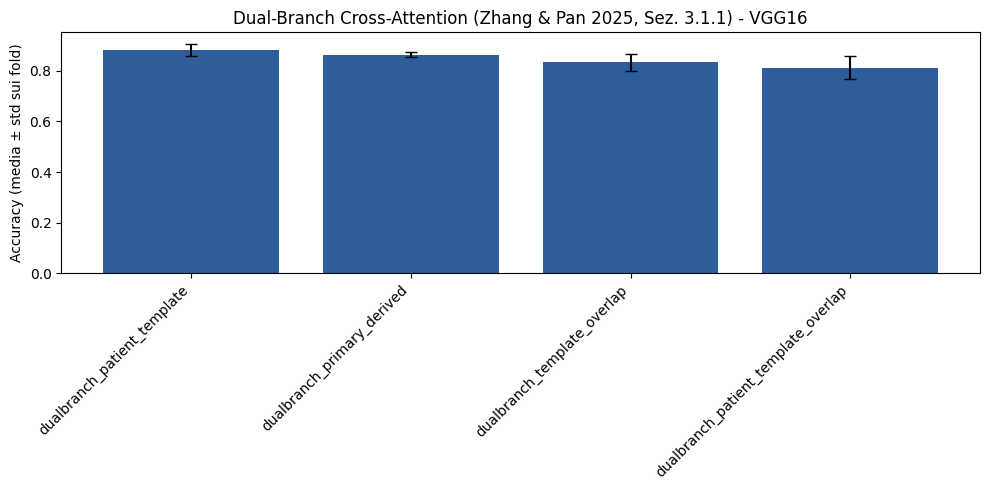

Grafico comparativo salvato in: /kaggle/working/outputs/ablation_results/dualbranch_crossattn_accuracy_comparison_vgg16.png


In [13]:

# Metriche: Accuracy, Sensitivity, Specificity, AUC, AUPR
# Una riga per ciascuno dei 7 canali, usando le metriche aggregate out-of-fold
# (le più rappresentative per un confronto diretto tra canali).
paper_style_rows = []
for r in ablation_results:
    row = {'Esperimento': r['experiment_name'], 'Canali': ', '.join(r['channels'])}
    row.update(r['oof_paper_metrics'])
    paper_style_rows.append(row)
 
paper_style_df = pd.DataFrame(paper_style_rows)[
    ['Esperimento', 'Canali', 'Accuracy', 'Sensitivity', 'Specificity', 'AUC', 'AUPR']
]
 
print("\n" + "#"*70)
print("#  ESPERIMENTO 2 - ABLATION 7 CANALI: Accuracy, Sensitivity, Specificity, AUC, AUPR")
print("#  (metriche aggregate out-of-fold, una riga per canale)")
print("#"*70)
print(paper_style_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
 
paper_metrics_path = RESULTS_DIR / 'paper_style_metrics_dualbranch_crossattn_vgg16.csv'
paper_style_df.to_csv(paper_metrics_path, index=False)
print(f"\nMetriche stile paper salvate in: {paper_metrics_path}")
 
# Grafico comparativo (Accuracy media ± std per esperimento)
plt.figure(figsize=(10, 5))
order = comparison_df['Esperimento']
plt.bar(order, comparison_df['Accuracy_mean'], yerr=comparison_df['Accuracy_std'],
        capsize=4, color='#2f5d9c')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Accuracy (media ± std sui fold)')
plt.title('Dual-Branch Cross-Attention (Zhang & Pan 2025, Sez. 3.1.1) - VGG16')
plt.tight_layout()
plot_path = RESULTS_DIR / 'dualbranch_crossattn_accuracy_comparison_vgg16.png'
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Grafico comparativo salvato in: {plot_path}")